# In this mini project we'll do option pricing using monte carlo and then accelerate it with CUDA

In [2]:
import numpy as np
import time
import math
from numba import cuda
from scipy.stats import norm
import cupy as cp
import matplotlib.pyplot as plt

In [3]:
S0    = 100.0    # Initial stock price
K     = 105.0    # Strike price which is the price
r     = 0.05     # Risk-free interest rate which is the guaranteed ROI
sigma = 0.2      # Volatility in percentages
T     = 1.0      # Time to maturity in years
N     = 100_000_000  # Number of simulations

In [4]:
def monte_carlo_sequential(S0, K, r, sigma, T, N):
    payoffs = np.zeros(N)
    # This is the naive loop monte carlo sequential option pricing
    # It is very slow due to the absence of parallelism and vectorization
    for i in range(N):
        Z = np.random.standard_normal()
        # This is the geometric brownian motion
        ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
        payoffs[i] = max(ST - K, 0.0)

    option_price = np.exp(-r * T) * np.mean(payoffs)
    return option_price

In [5]:
# Perf counter and measure of time
start = time.perf_counter()
price = monte_carlo_sequential(S0, K, r, sigma, T, N)
end = time.perf_counter()
sequential_time = end - start
print(f"\n  Sequential Time  : {sequential_time:.4f} seconds")
print(price)


  Sequential Time  : 294.8211 seconds
8.023092970974227


In [6]:
def monte_carlo_option_cpu(S0, K, r, sigma, T, N):
    # This is the Numpy version which is lightning fast compared to the naive loop version

    Z = np.random.standard_normal(N)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(S_T - K, 0)
    price = np.exp(-r * T) * np.mean(payoffs)
    return price
# Why didn't we use loops here ?
# Because first by definition loops are very slow, and for monte carlo option pricing we consider that it is a european option which means that we only care about the price at maturity which means that N and N-1 are independent

In [7]:
start = time.perf_counter()
numpy_price = monte_carlo_option_cpu(S0, K, r, sigma, T, N)
end = time.perf_counter()
numpy_sequential_time = end - start
print(numpy_price)
print(f"\n  Sequential Time  : {numpy_sequential_time:.4f} seconds")

8.021868012623054

  Sequential Time  : 7.4372 seconds


In [8]:
@cuda.jit
def monte_carlo_kernel(S0, K, r, sigma, T, seeds, payoffs):
    i = cuda.grid(1)
    if i >= payoffs.shape[0]:
        return

    # Here each thread generates it's own random number as a starting point using LCG algorithme
    seed = seeds[i]
    seed = (seed * 1664525 + 1013904223) & 0xFFFFFFFF
    u = seed / 0xFFFFFFFF

    seed2 = (seed * 1664525 + 1013904223) & 0xFFFFFFFF
    u2 = seed2 / 0xFFFFFFFF
    # Box muller to have a gaussian with mean 0 and standard deviation 1 N(0,1)
    Z = math.sqrt(-2.0 * math.log(u + 1e-10)) * math.cos(2.0 * math.pi * u2)

    # Each thread computes its own S_T and payoff
    S_T = S0 * math.exp((r - 0.5 * sigma**2) * T + sigma * math.sqrt(T) * Z)
    payoffs[i] = max(S_T - K, 0.0)



In [9]:
def monte_carlo_naive_gpu(S0, K, r, sigma, T, N):
    # Prepare random seeds — one per thread
    seeds = np.random.randint(0, 2**31, size=N, dtype=np.int64)
    seeds_dev = cuda.to_device(seeds)
    payoffs_dev = cuda.device_array(N, dtype=np.float64)

    threads_per_block = 256
    blocks = (N + threads_per_block - 1) // threads_per_block

    monte_carlo_naive_kernel[blocks, threads_per_block](
        S0, K, r, sigma, T, seeds_dev, payoffs_dev
    )
    cuda.synchronize()

    payoffs = payoffs_dev.copy_to_host()
    return np.exp(-r * T) * np.mean(payoffs)
    # IN GPU
    # Compute option price
    price = np.exp(-r * T) * np.mean(payoffs)
    return price

In [10]:
start = time.perf_counter()
price_GPU = monte_carlo_naive_gpu(S0, K, r, sigma, T, N)
end = time.perf_counter()

gpu_naive_time = end - start
print(f"\n  GPU Time  : {gpu_naive_time:.4f} seconds")
print(price_GPU)


  GPU Time  : 4.0292 seconds
8.019410116458339


In [11]:
def monte_carlo_optimized_gpu(S0, K, r, sigma, T, N):
    # Generate all N random numbers directly on GPU
    Z = cp.random.standard_normal(N)
    # Brownian motion
    S_T = S0 * cp.exp((r - 0.5 * sigma**2) * T + sigma * cp.sqrt(T) * Z)

    payoffs = cp.maximum(S_T - K, 0)

    price = float(cp.exp(-r * T) * cp.mean(payoffs))
    return price

In [12]:
start = time.perf_counter()
price = monte_carlo_optimized_gpu(S0, K, r, sigma, T, N)
end = time.perf_counter()
optimized_gpu_time = end - start
print(f"\n  GPU Time  : {optimized_gpu_time:.4f} seconds")
print(price)


  GPU Time  : 0.4556 seconds
8.02147049229808


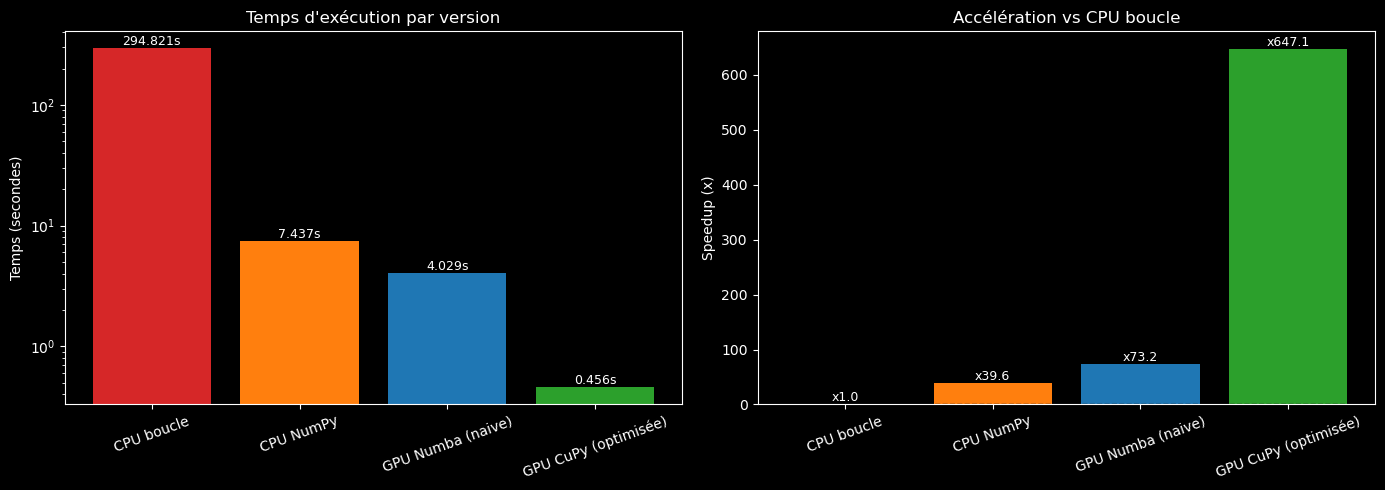

In [13]:
# Récupère les timings calculés plus haut dans le notebook
labels = ["CPU boucle", "CPU NumPy", "GPU Numba (naive)", "GPU CuPy (optimisée)"]
times = np.array([
    sequential_time,
    numpy_sequential_time,
    gpu_naive_time,
    optimized_gpu_time
], dtype=float)

speedups = times[0] / times

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphe 1 : temps d'exécution ---
bars1 = axes[0].bar(labels, times, color=["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"])
axes[0].set_title("Temps d'exécution par version")
axes[0].set_ylabel("Temps (secondes)")
axes[0].set_yscale("log")  # utile si les écarts sont très grands
axes[0].tick_params(axis="x", rotation=20)

for b, t in zip(bars1, times):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height(), f"{t:.3f}s",
                 ha="center", va="bottom", fontsize=9)

bars2 = axes[1].bar(labels, speedups, color=["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"])
axes[1].set_title("Accélération vs CPU boucle")
axes[1].set_ylabel("Speedup (x)")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[1].tick_params(axis="x", rotation=20)

for b, s in zip(bars2, speedups):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height(), f"x{s:.1f}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()